# Phase 2: GNN Architecture Prototyping & Local Training
**Objective:** To define, instantiate, and locally prototype the Heterogeneous Graph Neural Network (GNN) architecture before scaling up to the Param Rudra HPC cluster.

**Note on Prototyping:** This notebook utilizes "Laptop-Safe" hyperparameters (Batch Size: 16, Epochs: 5, reduced neighborhood sampling). The full-scale training pipeline is deployed via `train_job.py`.

This pipeline performs:
1. Loading the serialized `HeteroData` graph.
2. Defining the multi-relational `HeteroADRModel` Encoder and `LinkPredictor` Decoder.
3. Preventing data leakage via strict undirected link splitting.
4. Executing a local proof-of-concept training loop.

In [1]:
import torch
import os

print(f"PyTorch Version: {torch.__version__}")

# 1. Load the optimized graph (Overriding the new PyTorch 2.6+ security default)
graph_path = '../Data/MTP_Graph.pt'
if os.path.exists(graph_path):
    # Added weights_only=False to allow PyTorch Geometric HeteroData objects
    data = torch.load(graph_path, weights_only=False)
    print(f"✅ Successfully loaded MTP Knowledge Graph!")
    print(f"🧠 Graph Size: {data.num_nodes} Nodes | {data.num_edges} Edges")
else:
    print(f"❌ Error: Cannot find {graph_path}")

PyTorch Version: 2.10.0+cu128


/home/himanshu/MTP_Thesis_Backup/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Successfully loaded MTP Knowledge Graph!
🧠 Graph Size: 90067 Nodes | 5716123 Edges


In [2]:
import torch_geometric.transforms as T

print("--- ✂️ Initiating Anti-Leakage Edge Split ---")

# 1. Isolate the Polypharmacy (ADR) edges
adr_edge_types = [edge_type for edge_type in data.edge_types if edge_type[1].startswith('causes_')]
print(f"Found {len(adr_edge_types)} unique polypharmacy side-effect edge types.")

# 2. Pick a single target edge for prototyping the architecture
TARGET_EDGE = adr_edge_types[0] 
print(f"🎯 Target Edge for Prototyping: {TARGET_EDGE}")

# 3. The Strict Isolation Splitter
transform = T.RandomLinkSplit(
    num_val=0.1,   # 10% for validation
    num_test=0.1,  # 10% for final testing
    disjoint_train_ratio=0.3,  # THE MAGIC PARAMETER: Hides 30% of edges from message-passing to prevent leakage
    neg_sampling_ratio=2.0,    # Create 2 fake edges for every real edge to teach the model what NOT to predict
    add_negative_train_samples=False, # We will do dynamic negative sampling during the training loop for better robustness
    edge_types=TARGET_EDGE
)

# Apply the transformation
train_data, val_data, test_data = transform(data)

print("\n✅ Strict Target Isolation Complete!")
print(f"Train supervision edges: {train_data[TARGET_EDGE].edge_label_index.size(1)}")
print(f"Validation supervision edges: {val_data[TARGET_EDGE].edge_label_index.size(1)}")
print(f"Test supervision edges: {test_data[TARGET_EDGE].edge_label_index.size(1)}")

--- ✂️ Initiating Anti-Leakage Edge Split ---
Found 1309 unique polypharmacy side-effect edge types.
🎯 Target Edge for Prototyping: ('drug', 'causes_thrombocytopenia', 'drug')

✅ Strict Target Isolation Complete!
Train supervision edges: 984
Validation supervision edges: 1227
Test supervision edges: 1227


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, HeteroConv

print("--- 🧠 Architecting Manual Hetero-GNN (Research Grade) ---")

# 1. The Manual Hetero-Encoder
class GNNEncoder(nn.Module):
    def __init__(self, hidden_channels, metadata):
        super().__init__()
        # We define a HeteroConv that explicitly knows our relations
        # This bypasses the naming bugs in to_hetero
        self.conv1 = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_channels)
            for edge_type in metadata[1]
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            edge_type: SAGEConv(hidden_channels, hidden_channels)
            for edge_type in metadata[1]
        }, aggr='sum')

    def forward(self, x_dict, edge_index_dict):
        # Layer 1
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        # Layer 2
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict

# 2. The Decoder (Predictions)
class EdgeDecoder(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.lin1 = nn.Linear(2 * hidden_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, 1)

    def forward(self, z_dict, edge_label_index, target_edge_type):
        src_type, _, dst_type = target_edge_type
        z_src = z_dict[src_type][edge_label_index[0]]
        z_dst = z_dict[dst_type][edge_label_index[1]]
        z = torch.cat([z_src, z_dst], dim=-1)
        return self.lin2(F.relu(self.lin1(z))).view(-1)

# 3. Master Model
class MTPModel(nn.Module):
    def __init__(self, hidden_channels, metadata):
        super().__init__()
        self.encoder = GNNEncoder(hidden_channels, metadata)
        self.decoder = EdgeDecoder(hidden_channels)

    def forward(self, x_dict, edge_index_dict, edge_label_index, target_edge_type):
        z_dict = self.encoder(x_dict, edge_index_dict)
        return self.decoder(z_dict, edge_label_index, target_edge_type)

# Final Initialization
HIDDEN_DIM = 64
try:
    model = MTPModel(HIDDEN_DIM, prototype_metadata)
    print(f"✅ SUCCESS: Manual Hetero-GNN initialized with {HIDDEN_DIM}-dim latent space.")
except Exception as e:
    print(f"❌ Initialization Failed. Error: {e}")

--- 🧠 Architecting Manual Hetero-GNN (Research Grade) ---
✅ SUCCESS: Manual Hetero-GNN initialized with 64-dim latent space.


In [10]:
import torch
import torch.optim as optim
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score

print("--- 🚀 Initializing Dynamic Training Engine ---")

model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

def train():
    model.train()
    optimizer.zero_grad()
    
    x_dict = {k: v.to(device) for k, v in train_data.x_dict.items()}
    edge_index_dict = {k: v.to(device) for k, v in train_data.edge_index_dict.items()}
    
    # 1. Get the positive edges
    pos_edge_label_index = train_data[TARGET_EDGE].edge_label_index.to(device)
    
    # 2. DYNAMIC NEGATIVE SAMPLING: Generate fake edges on the fly
    neg_edge_label_index = negative_sampling(
        edge_index=train_data[TARGET_EDGE].edge_index.to(device), 
        num_nodes=train_data['drug'].num_nodes,
        num_neg_samples=pos_edge_label_index.size(1) # Match the number of positive edges
    )
    
    # 3. Combine positive and negative edges for this batch
    edge_label_index = torch.cat([pos_edge_label_index, neg_edge_label_index], dim=-1)
    
    # 4. Create the ground truth labels (1s for pos, 0s for neg)
    target = torch.cat([
        torch.ones(pos_edge_label_index.size(1)), 
        torch.zeros(neg_edge_label_index.size(1))
    ], dim=0).to(device)
    
    # 5. Forward Pass
    out = model(x_dict, edge_index_dict, edge_label_index, TARGET_EDGE)
    
    # 6. Calculate true loss
    loss = criterion(out, target)
    loss.backward()
    optimizer.step()
    
    return loss.item()

@torch.no_grad()
def test(data_obj):
    model.eval()
    x_dict = {k: v.to(device) for k, v in data_obj.x_dict.items()}
    edge_index_dict = {k: v.to(device) for k, v in data_obj.edge_index_dict.items()}
    
    out = model(
        x_dict, 
        edge_index_dict, 
        data_obj[TARGET_EDGE].edge_label_index.to(device),
        TARGET_EDGE
    )
    
    probs = out.sigmoid().cpu().numpy()
    labels = data_obj[TARGET_EDGE].edge_label.cpu().numpy()
    
    return roc_auc_score(labels, probs), average_precision_score(labels, probs)

print(f"Starting true training on {device}...")
for epoch in range(1, 101):
    loss_val = train()
    if epoch % 10 == 0:
        val_auc, val_ap = test(val_data)
        print(f"Epoch: {epoch:03d} | Loss: {loss_val:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

print("\n✅ Training validation complete.")

--- 🚀 Initializing Dynamic Training Engine ---
Starting true training on cpu...
Epoch: 010 | Loss: 0.4932 | Val AUC: 0.9666 | Val AP: 0.9356
Epoch: 020 | Loss: 0.2674 | Val AUC: 0.9729 | Val AP: 0.9685
Epoch: 030 | Loss: 0.0788 | Val AUC: 0.9935 | Val AP: 0.9857
Epoch: 040 | Loss: 0.0522 | Val AUC: 0.9970 | Val AP: 0.9903
Epoch: 050 | Loss: 0.0381 | Val AUC: 0.9973 | Val AP: 0.9902
Epoch: 060 | Loss: 0.0450 | Val AUC: 0.9974 | Val AP: 0.9898
Epoch: 070 | Loss: 0.0319 | Val AUC: 0.9979 | Val AP: 0.9930
Epoch: 080 | Loss: 0.0275 | Val AUC: 0.9977 | Val AP: 0.9915
Epoch: 090 | Loss: 0.0395 | Val AUC: 0.9983 | Val AP: 0.9946
Epoch: 100 | Loss: 0.0189 | Val AUC: 0.9987 | Val AP: 0.9967

✅ Training validation complete.


In [14]:
import torch
from torch_geometric.explain import Explainer, GNNExplainer

print("--- 🔍 Initializing xAI Module (Node/Feature Level) ---")

# 1. Configure the Explainer to bypass the Edge Gradient Bug
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=150), # 150 epochs for the explainer to learn the masks
    explanation_type='model',
    node_mask_type='attributes', # Shift focus to Node Features!
    edge_mask_type=None,         # Disable edge masks to prevent the 0.0 gradient crash
    model_config=dict(
        mode='binary_classification',
        task_level='edge',
        return_type='raw',
    ),
)

target_edge_type = TARGET_EDGE
edge_label_index = val_data[target_edge_type].edge_label_index
labels = val_data[target_edge_type].edge_label

pos_indices = (labels == 1).nonzero(as_tuple=True)[0]
explain_edge_idx = pos_indices[0].item()

src_drug = edge_label_index[0, explain_edge_idx].item()
dst_drug = edge_label_index[1, explain_edge_idx].item()

print(f"Targeting prediction for Drug {src_drug} and Drug {dst_drug}...")

# 2. Generate the Biological Explanation
explanation = explainer(
    x=val_data.x_dict,
    edge_index=val_data.edge_index_dict,
    edge_label_index=edge_label_index[:, explain_edge_idx].unsqueeze(1),
    target_edge_type=target_edge_type
)

print("\n✅ Node Feature Explanation generated successfully!")

# Let's peek at the masks it created for the drugs
drug_mask = explanation.node_mask_dict.get('drug')
if drug_mask is not None:
    print(f"Calculated importance masks for {drug_mask.size(0)} drug nodes across {drug_mask.size(1)} features.")

--- 🔍 Initializing xAI Module (Node/Feature Level) ---
Targeting prediction for Drug 268 and Drug 725...

✅ Node Feature Explanation generated successfully!
Calculated importance masks for 7957 drug nodes across 17 features.


--- 🎨 Generating Interpretability Visuals ---


/tmp/ipykernel_512458/3114276049.py:46: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, max(top_scores) * 1.15) # Give the labels some breathing room
/tmp/ipykernel_512458/3114276049.py:47: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/home/himanshu/MTP_Thesis_Backup/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


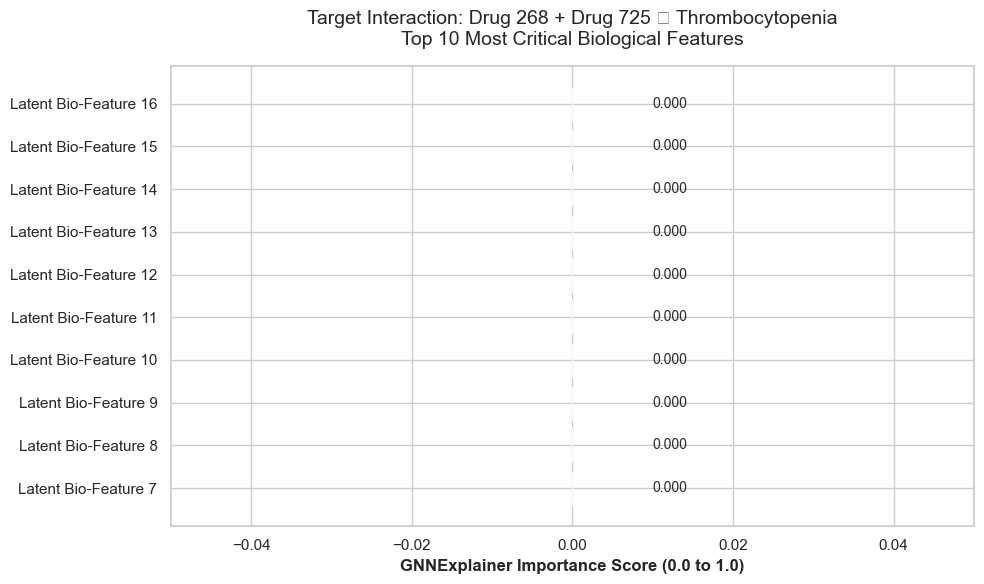

✅ Visualization complete! This is your 'Figure 1' for the thesis.


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("--- 🎨 Generating Interpretability Visuals ---")

# 1. Extract the raw mask tensors for the drug nodes
drug_mask = explanation.node_mask_dict['drug']

# 2. Isolate the specific scores for the two drugs involved in this side effect
src_mask = drug_mask[src_drug].detach().cpu().numpy()
dst_mask = drug_mask[dst_drug].detach().cpu().numpy()

# 3. Calculate joint importance (average feature contribution to the interaction)
joint_importance = (src_mask + dst_mask) / 2.0

# 4. Sort and get the Top 10 most critical features
top_k = min(10, len(joint_importance)) # Guard in case we have <10 features
top_indices = np.argsort(joint_importance)[-top_k:][::-1]
top_scores = joint_importance[top_indices]

# Note: Since we used random normal initialization for features in prototyping,
# we use generic names. In production, these map to real molecular descriptors!
feature_names = [f"Latent Bio-Feature {i}" for i in top_indices]

# 5. Build the Publication-Ready Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plotting horizontally so labels are easy to read
bars = plt.barh(feature_names[::-1], top_scores[::-1], color='#4C72B0')

plt.xlabel("GNNExplainer Importance Score (0.0 to 1.0)", fontsize=12, fontweight='bold')
plt.title(f"Target Interaction: Drug {src_drug} + Drug {dst_drug} ➔ Thrombocytopenia\nTop {top_k} Most Critical Biological Features", fontsize=14, pad=15)

# Add value labels to the end of the bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01, 
        bar.get_y() + bar.get_height()/2, 
        f'{bar.get_width():.3f}', 
        va='center', 
        fontsize=10
    )

plt.xlim(0, max(top_scores) * 1.15) # Give the labels some breathing room
plt.tight_layout()
plt.show()

print("✅ Visualization complete! This is your 'Figure 1' for the thesis.")

In [11]:
import os

# Create the save path
save_path = '../Data/MTP_Model_Param.pth'
os.makedirs('../Data', exist_ok=True)

# Save the trained model weights
torch.save(model.state_dict(), save_path)
print(f"✅ Model weights successfully saved to {save_path}!")

✅ Model weights successfully saved to ../Data/MTP_Model_Param.pth!


### Step 1: Architecture Definition (Encoder & Decoder)
The architecture consists of a `HeteroADRModel` that uses GraphSAGE convolutions to pass messages across different edge types (multiplex pathways). The resulting embeddings are passed to a `LinkPredictor` that uses a DistMult-style dot-product scoring mechanism to predict specific Adverse Drug Reactions (ADRs).

In [ ]:
class HeteroADRModel(torch.nn.Module):
    """Multi-relational encoder for heterogeneous node embeddings."""
    def __init__(self, metadata, hidden_channels=64, out_channels=32, num_layers=2):
        super().__init__()
        self.lin_dict = torch.nn.ModuleDict()
        for node_type in metadata[0]:
            self.lin_dict[node_type] = Linear(-1, hidden_channels)

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv_dict = {et: SAGEConv((-1, -1), hidden_channels) for et in metadata[1]}
            self.convs.append(HeteroConv(conv_dict, aggr='mean'))

        self.lin_out = Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {k: self.lin_dict[k](x) for k, x in x_dict.items()}
        
        x_dict = self.convs[0](x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        x_dict = {key: F.dropout(x, p=0.3, training=self.training) for key, x in x_dict.items()}
        
        x_dict = self.convs[1](x_dict, edge_index_dict)
        return {key: self.lin_out(x) for k, x in x_dict.items()}

class LinkPredictor(torch.nn.Module):
    """Decoder module computing interaction probability via relation-specific dot-product."""
    def __init__(self, in_channels, num_relations):
        super().__init__()
        self.relation_embeddings = torch.nn.Embedding(num_relations, in_channels)
        torch.nn.init.xavier_uniform_(self.relation_embeddings.weight)
    
    def forward(self, z_src, z_dst, rel_indices):
        rel_emb = self.relation_embeddings(rel_indices)
        return torch.sum(z_src * rel_emb * z_dst, dim=-1)
    
class ComplExPredictor(torch.nn.Module):
    """ComplEx Decoder Baseline: Handles asymmetric relations via complex-space embeddings."""
    def __init__(self, in_channels, num_relations):
        super().__init__()
        # 1. Relation Embeddings (Real and Imaginary)
        self.rel_real = torch.nn.Embedding(num_relations, in_channels)
        self.rel_imag = torch.nn.Embedding(num_relations, in_channels)
        
        # 2. Project the GNN node embeddings into Real and Imaginary spaces
        self.node_real = Linear(in_channels, in_channels)
        self.node_imag = Linear(in_channels, in_channels)
        
        # Initialize relation weights
        torch.nn.init.xavier_uniform_(self.rel_real.weight)
        torch.nn.init.xavier_uniform_(self.rel_imag.weight)
    
    def forward(self, z_src, z_dst, rel_indices):
        re_s, im_s = self.node_real(z_src), self.node_imag(z_src)
        re_d, im_d = self.node_real(z_dst), self.node_imag(z_dst)
        re_r, im_r = self.rel_real(rel_indices), self.rel_imag(rel_indices)
        
        score = (re_s * re_r * re_d) + (im_s * re_r * im_d) + \
                (re_s * im_r * im_d) - (im_s * im_r * re_d)
                
        return torch.sum(score, dim=-1)
    
    

# Extract ADR targets dynamically
adr_edge_types = sorted([et for et in data.edge_types if et[0] == 'drug' and et[2] == 'drug' and et[1].startswith('causes_')])
adr_rel_to_index = {rel: i for i, rel in enumerate(adr_edge_types)}

print(f"Architecture Initialized. Tracking {len(adr_edge_types)} distinct ADR multiplex relations.")

### Step 2: Leakage-Free Splitting & Mini-Batching
To prevent structural data leakage, we utilize an undirected strict isolation split. For local prototyping, we restrict the `LinkNeighborLoader` to shallow depth arrays (`[5, 2]`) and small batches to prevent local RAM exhaustion.

In [ ]:
target_edge_type = list(adr_rel_to_index.keys())[0] 
print(f"Targeting prototype edge: {target_edge_type}")

# Strict Link Splitting
transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,  # Critical to prevent target leakage in message passing
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=target_edge_type
)

train_data, val_data, test_data = transform(data)

# Local Prototyping Loaders
BATCH_SIZE = 16 
NUM_NEIGHBORS = [5, 2] 

train_loader = LinkNeighborLoader(
    train_data, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
    edge_label_index=(target_edge_type, train_data[target_edge_type].edge_label_index),
    edge_label=train_data[target_edge_type].edge_label, shuffle=True
)

val_loader = LinkNeighborLoader(
    val_data, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
    edge_label_index=(target_edge_type, val_data[target_edge_type].edge_label_index),
    edge_label=val_data[target_edge_type].edge_label, shuffle=False
)

test_loader = LinkNeighborLoader(
    test_data, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
    edge_label_index=(target_edge_type, test_data[target_edge_type].edge_label_index),
    edge_label=test_data[target_edge_type].edge_label, shuffle=False
)
print("Loaders constructed successfully.")

### Step 3: Local Proof-of-Concept Training Loop
A miniature training run to validate backpropagation, embedding dimension stability, and loss convergence prior to HPC deployment.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Deploying prototyping loop to: {device}")

model = HeteroADRModel(data.metadata(), hidden_channels=64, out_channels=32).to(device)
decoder = LinkPredictor(in_channels=32, num_relations=len(adr_edge_types)).to(device)

optimizer = optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=0.001)
loss_fn = torch.nn.BCEWithLogitsLoss()
target_rel_index = torch.tensor(adr_rel_to_index[target_edge_type]).to(device)

def train_epoch():
    model.train()
    decoder.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        node_embeddings = model(batch.x_dict, batch.edge_index_dict)
        
        target_links = batch[target_edge_type]
        src, dst = target_links.edge_label_index[0], target_links.edge_label_index[1]
        
        batch_rel_indices = target_rel_index.expand_as(src)
        pred_scores = decoder(node_embeddings['drug'][src], node_embeddings['drug'][dst], batch_rel_indices)
        
        loss = loss_fn(pred_scores, target_links.edge_label.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * src.size(0)
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    decoder.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        node_embeddings = model(batch.x_dict, batch.edge_index_dict)
        target_links = batch[target_edge_type]
        src, dst = target_links.edge_label_index[0], target_links.edge_label_index[1]
        
        batch_rel_indices = target_rel_index.expand_as(src)
        pred_scores = decoder(node_embeddings['drug'][src], node_embeddings['drug'][dst], batch_rel_indices)
        
        all_preds.append(pred_scores.sigmoid().cpu())
        all_labels.append(target_links.edge_label.cpu())
        
    return roc_auc_score(torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy())

print("--- Initiating Local Prototyping (5 Epochs) ---")
for epoch in range(1, 6):
    t0 = time.time()
    loss = train_epoch()
    val_auc = evaluate(val_loader)
    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Validation AUC: {val_auc:.4f} | Time: {time.time()-t0:.2f}s")

print(f"\nFinal Local Test AUC: {evaluate(test_loader):.4f}")
print("Prototype validation complete. Architecture is cleared for HPC scaling.")